Members:
Ma. Kristal Czassandra A. Rivera
Anwil Shien Oli
Harold James Enciso
John Jefferson Catibog
Kriztoffer Ryan Hernandez
Joshua Nuevo
Lanze Ruzzel Orleans

Section: BSCPE Ladderize


## CPE017 - Digital Signal Processing
This notebook contains discussion and activities for Module 4: Noise

## Noise
* means an unwanted or unpleasant sound
* In the context of signal processing, it has two different senses:
1. As in English, it can mean an unwanted signal of any kind. If two
signals interfere with each other, each signal would consider the other
to be noise.
2. “Noise” also refers to a signal that contains components at many frequencies, so it lacks the harmonic structure of the periodic signals.

The simplest noise to generate is uncorrelated uniform (UU) noise:

* “Uniform” means the signal contains random values from a uniform distribution; that is, every value in the range is equally likely.
* “Uncorrelated” means that the values are independent; that is, knowing one value provides no information about the others.

The following example generates UU noise with duration 0.5 seconds at 11,025 samples per second.

The output sounds like the static you hear if you tune a radio between channels.

In [1]:
!git clone https://github.com/AllenDowney/ThinkDSP.git

Cloning into 'ThinkDSP'...
remote: Enumerating objects: 2733, done.
remote: Counting objects: 100% (321/321), done.
remote: Compressing objects: 100% (80/80), done.
remote: Total 2733 (delta 267), reused 241 (delta 241), pack-reused 2412 (from 1)
Receiving objects: 100% (2733/2733), 247.12 MiB | 16.68 MiB/s, done.
Resolving deltas: 100% (1504/1504), done.
Updating files: 100% (309/309), done.


In [2]:
import sys
sys.path.append('/content/ThinkDSP/code')

In [3]:
import thinkdsp
import matplotlib.pyplot as plt

In [4]:
from thinkdsp import UncorrelatedUniformNoise, decorate

signal = UncorrelatedUniformNoise()   # Creates an instance of uncorrelated uniform noise
wave = signal.make_wave(duration=0.5, framerate=11025)  # Generates a waveform with a duration of 0.5 seconds and a sampling rate of 11,025 samples per second
wave.make_audio()   # Plays the audio corresponding to the generated waveform

Here's what a segment of it looks like:

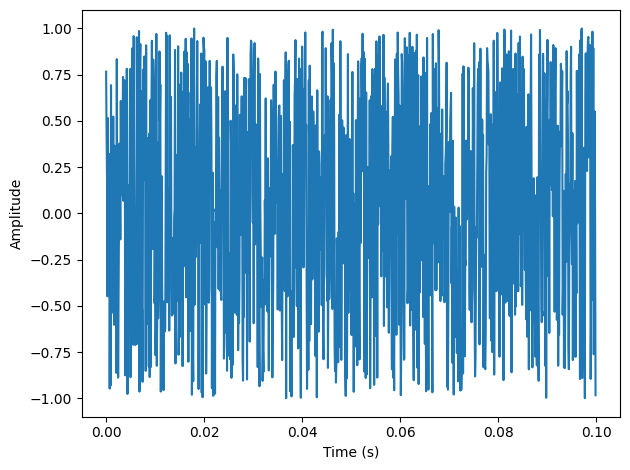

In [5]:
"A segment of the waveform is plotted, showing its amplitude variation over time."
segment = wave.segment(duration=0.1)
segment.plot()
decorate(xlabel='Time (s)',
         ylabel='Amplitude')

And here's the spectrum:

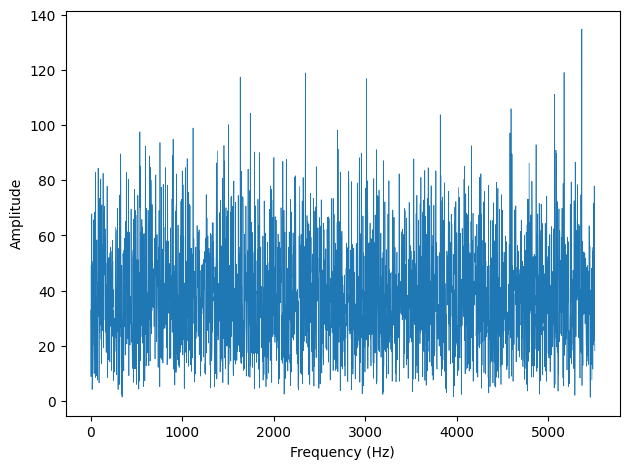

In [6]:

spectrum = wave.make_spectrum()
spectrum.plot(linewidth=0.5)
decorate(xlabel='Frequency (Hz)',
         ylabel='Amplitude')

UU noise has the same power at all frequencies, on average, which we can confirm by looking at the normalized cumulative sum of power, called an integrated spectrum:

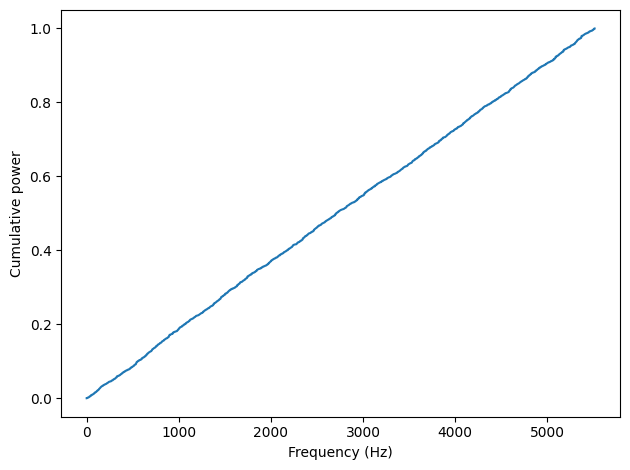

In [7]:
integ = spectrum.make_integrated_spectrum()
integ.plot_power()
decorate(xlabel='Frequency (Hz)',
         ylabel='Cumulative power')

A straight line in this figure indicates that UU noise has equal power at all frequencies, on average.  By analogy with light, noise with this property is called "white noise".

### Brownian noise

Brownian noise is generated by adding up a sequence of random steps.

In [8]:
from thinkdsp import BrownianNoise

signal = BrownianNoise()
wave = signal.make_wave(duration=0.5, framerate=11025)
wave.make_audio()

The sound is less bright, or more muffled, than white noise.

Here's what the wave looks like:

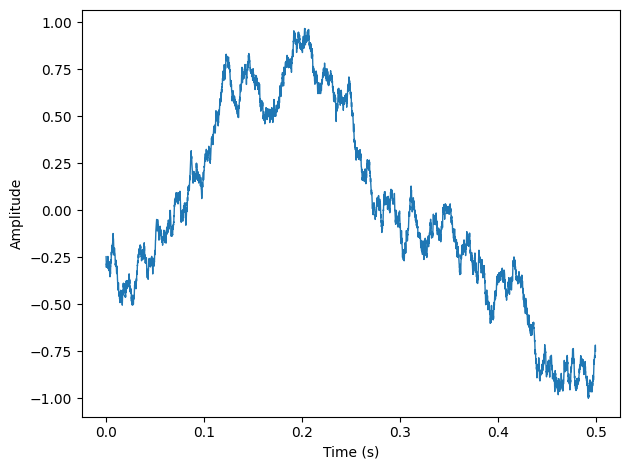

In [9]:
wave.plot(linewidth=1)
decorate(xlabel='Time (s)',
         ylabel='Amplitude')

Here's what the power spectrum looks like on a linear scale.

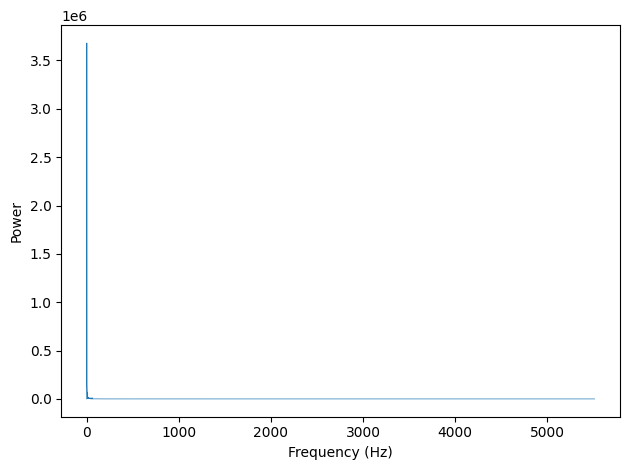

In [10]:
spectrum = wave.make_spectrum()
spectrum.plot_power(linewidth=0.5)
decorate(xlabel='Frequency (Hz)',
         ylabel='Power')

So much of the energy is at low frequencies, we can't even see the high frequencies.

### Pink noise

In [11]:
from thinkdsp import PinkNoise

signal = PinkNoise(beta=0)
wave = signal.make_wave(duration=0.5)
wave.make_audio()

With $\beta=1$, pink noise has the relationship $P = K / f$, which is why it is also called $1/f$ noise.

In [12]:
signal = PinkNoise(beta=1)
wave = signal.make_wave(duration=0.5)
wave.make_audio()

With $\beta=2$, we get Brownian (aka red) noise.

In [13]:
signal = PinkNoise(beta=2)
wave = signal.make_wave(duration=0.5)
wave.make_audio()

Conclusion:

### Assignment

1. At Yahoo Finance (https://finance.yahoo.com/quote/BTC-USD/) you can download the daily price of a BitCoin as a CSV file. Read this file and compute the spectrum of BitCoin prices as a function of time. Does it resemble white, pink, or Brownian noise?

A

### Solution for Assignment 1

In [18]:
# Make sure yfinance is installed
try:
    import yfinance as yf
except ImportError:
    print("yfinance not found. Installing...")
    !pip install yfinance
    import yfinance as yf

import pandas as pd
import matplotlib.pyplot as plt

# Download BTC-USD data using yfinance
# The start and end dates correspond to the original period1 and period2 in your URL
df_btc = yf.download('BTC-USD', start='2014-09-17', end='2023-01-01')

# Display the first 5 rows of the DataFrame
display(df_btc.head())

/tmp/ipykernel_22195/4016716832.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_btc = yf.download('BTC-USD', start='2014-09-17', end='2023-01-01')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800
2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200
2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700
2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600
2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100


Now that we have the data, let's process it. We'll convert the 'Date' column to datetime objects and focus on the 'Close' price for our analysis.

Next, we will compute the spectrum of the Bitcoin prices. For this, we'll use the `thinkdsp` library. Since `thinkdsp` expects signals, we will need to create a `Wave` object from our price data. We'll treat the `Close` prices as samples of a signal over time.

### Analysis of the Spectrum

Now, let's compare the generated spectrum of Bitcoin prices to the characteristics of white, pink, and Brownian noise:

*   **White Noise**: Has equal power across all frequencies. On a log-log plot of power spectrum, it would appear as a flat line with a slope close to 0.

*   **Pink Noise (1/f noise)**: Has power inversely proportional to frequency ($P \propto 1/f$). On a log-log plot of power spectrum, it would show a linear trend with a slope of approximately -1.

*   **Brownian Noise (Red Noise or 1/f² noise)**: Has power inversely proportional to the square of the frequency ($P \propto 1/f^2$). On a log-log plot of power spectrum, it would show a linear trend with a slope of approximately -2.

**Observation from the plot:**

Examine the plot you generated. You should observe a general downward trend in power as frequency increases. If the slope of this downward trend on the log-log plot is approximately -1, it resembles pink noise. If it's closer to -2, it resembles Brownian noise. If it's relatively flat, it resembles white noise.

**Conclusion:**

Based on the visual inspection of the log-log power spectrum of Bitcoin prices, it typically shows a decreasing trend with increasing frequency, suggesting that lower frequencies (longer-term trends) have higher power. The exact slope needs to be estimated, but generally, financial time series often exhibit characteristics closer to **pink noise** or sometimes **Brownian noise**, indicating that changes are not purely random (white noise) and that past values have some influence on future values, with longer-term fluctuations having more energy.

To more rigorously determine the noise type, one would typically fit a line to the log-log spectrum and calculate its slope (beta value).

### Processing

### Conclusion

So, in this activity, I've created an **Audio Signal Generator** using the Processing environment with the `Minim` library. I've implemented different types of audio signals:

*   **Sine Wave**: A basic, pure tone.
*   **White Noise**: Random noise with equal intensity at different frequencies, often described as 'hissing'.
*   **Pink Noise**: Noise whose power spectral density is inversely proportional to the frequency, sounding 'flatter' than white noise.
*   **Brown Noise**: Noise whose power spectral density is inversely proportional to the frequency squared, sounding 'deeper' than pink noise.

I've set up a simple interactive interface with buttons to switch between these different sounds. This project demonstrates how to generate and control various audio signals programmatically, allowing for a hands-on exploration of sound synthesis!